In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from transformers import GPT2LMHeadModel, GPT2Tokenizer
import torch.nn.functional as F

tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
model = GPT2LMHeadModel.from_pretrained("gpt2")
model.eval()

print("Ready!")
print(f"Total layers: {model.config.n_layer}")

c:\Users\devuser3\AppData\Roaming\uv\python\cpython-3.14.3-windows-x86_64-none\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 148/148 [00:00<00:00, 6083.88it/s]


Ready!
Total layers: 12


In [2]:
text = "The cat sat on the"
inputs = tokenizer(text, return_tensors="pt")

# Normal output (no noise)
with torch.no_grad():
    normal_output = model(**inputs)
normal_logits = normal_output.logits[0, -1, :]
normal_probs  = torch.softmax(normal_logits, dim=0)

# Top word without noise
top_word_id  = normal_probs.argmax().item()
top_word     = tokenizer.decode([top_word_id])
print(f"Normal top word: '{top_word}' ({normal_probs.max():.4f})")


noise_scale = 10.0
layer_impacts = []

for target_layer in range(12):
    
    def add_noise_hook(module, input, output):
        if isinstance(output, tuple):
            noisy = output[0] + torch.randn_like(output[0]) * noise_scale
            return (noisy,) + output[1:]
        return output + torch.randn_like(output) * noise_scale
    
   
    hook = model.transformer.h[target_layer].register_forward_hook(
        add_noise_hook)
    
    with torch.no_grad():
        noisy_output = model(**inputs)
    
    hook.remove()
    
    noisy_logits = noisy_output.logits[0, -1, :]
    noisy_probs  = torch.softmax(noisy_logits, dim=0)
    
    
    kl_div = F.kl_div(
        torch.log(noisy_probs + 1e-10),
        normal_probs + 1e-10,
        reduction='sum'
    ).item()
    
    layer_impacts.append(kl_div)
    print(f"Layer {target_layer+1:2d}: KL divergence = {kl_div:.4f}")

Normal top word: ' floor' (0.0764)
Layer  1: KL divergence = 6.5506
Layer  2: KL divergence = 9.4654
Layer  3: KL divergence = 6.5130
Layer  4: KL divergence = 5.3607
Layer  5: KL divergence = 9.0460
Layer  6: KL divergence = 5.5166
Layer  7: KL divergence = 5.2528
Layer  8: KL divergence = 5.6341
Layer  9: KL divergence = 3.6606
Layer 10: KL divergence = 2.6513
Layer 11: KL divergence = 3.0908
Layer 12: KL divergence = 1.4336


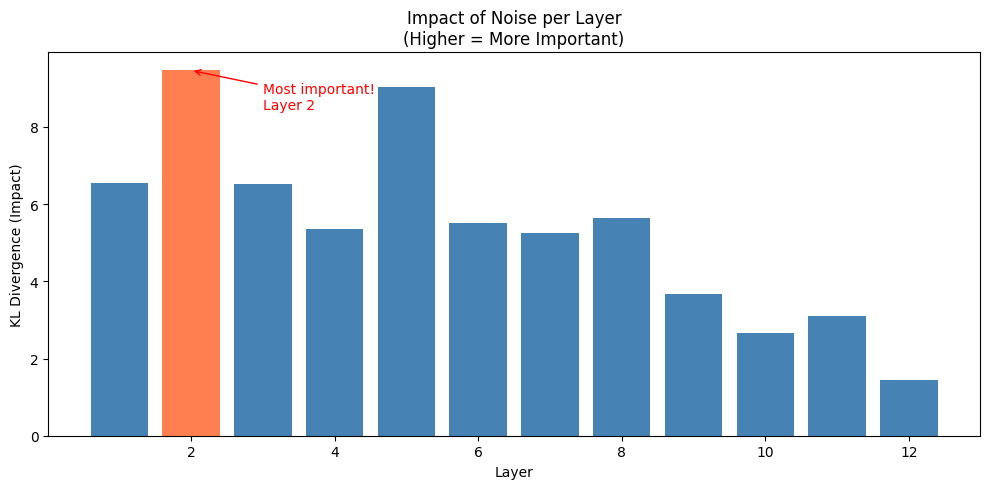

In [3]:
fig, ax = plt.subplots(figsize=(10, 5))

colors = ["coral" if x == max(layer_impacts) 
          else "steelblue" for x in layer_impacts]

ax.bar(range(1, 13), layer_impacts, color=colors)
ax.set_xlabel("Layer")
ax.set_ylabel("KL Divergence (Impact)")
ax.set_title("Impact of Noise per Layer\n(Higher = More Important)")


max_layer = layer_impacts.index(max(layer_impacts)) + 1
ax.annotate(f"Most important!\nLayer {max_layer}",
            xy=(max_layer, max(layer_impacts)),
            xytext=(max_layer + 1, max(layer_impacts) - 1),
            arrowprops=dict(arrowstyle="->", color="red"),
            color="red")

plt.tight_layout()
plt.show()

* **Early and middle layers** are more important.
* **Layer 2 and Layer 5** are the most critical — they are most affected by noise.
* **Last layers** are less sensitive to noise.
* The **“hooks” technique** is a core tool in Mechanistic Interpretability.
